# Основы дифференциального исчисления

> Конспект сделан по учебнику "Основы математического анализа. Часть 1". Ильин В.А., Позняк Э.Г. Глава «Основы дифференциального исчисления».<br>
> Конспект дополнен практическими примерами на Python/NumPy.

## Основые определения

- **Δx** — приращение аргумента, **Δy** — приращение функции: $\Delta y = f(x+\Delta x)-f(x)$.
- **Производная** — предел отношения приращений: $ f'(x)=\lim_{\Delta x\to 0}\frac{\Delta y}{\Delta x} $.
- **Дифференциал** (первого порядка) — главная линейная часть приращения: $dy=f'(x)\,dx$.

Везде ниже считаем, что функции определены в окрестности точки и имеют нужные пределы.


# 1. Приращение аргумента и функции

### 1.1. Приращение аргумента
Если функция $y=f(x)$ определена в окрестности точки $x$, то **приращением аргумента** называют число
$$
\Delta x = (x+\Delta x) - x.
$$
То есть это просто «маленький шаг» по оси $x$.

### 1.2. Приращение функции
Соответствующее **приращение функции**:
$$
\Delta y = f(x+\Delta x) - f(x).
$$

**Интуиция:** мы сдвинулись по $x$ на $\Delta x$ и смотрим, насколько изменилось значение $y$.  
В учебнике это вводится прямо в начале параграфа про производную.


In [1]:
import numpy as np

def delta_y(f, x, dx):
    return f(x + dx) - f(x)

f = np.sin
x0 = 1.0
dxs = np.array([1e-1, 1e-2, 1e-3, 1e-4])

print("x0 =", x0)
for dx in dxs:
    print(f"dx={dx: .0e}  Δy={delta_y(f, x0, dx): .8f}")

x0 = 1.0
dx= 1e-01  Δy= 0.04973638
dx= 1e-02  Δy= 0.00536086
dx= 1e-03  Δy= 0.00053988
dx= 1e-04  Δy= 0.00005403


### 1.3. Отношение приращений
Часто рассматривают
$$
\frac{\Delta y}{\Delta x} = \frac{f(x+\Delta x)-f(x)}{\Delta x},
$$
это **секущая**: средняя скорость изменения на отрезке длины $\Delta x$.  
Дальше мы «устремим» $\Delta x\to 0$ и получим производную (мгновенную скорость).


In [2]:
def ratio_increments(f, x, dx):
    return (f(x + dx) - f(x)) / dx

for dx in dxs:
    print(f"dx={dx: .0e}  Δy/Δx={ratio_increments(np.sin, x0, dx): .8f}  (ожидаем ~cos(x0)={np.cos(x0):.8f})")

dx= 1e-01  Δy/Δx= 0.49736375  (ожидаем ~cos(x0)=0.54030231)
dx= 1e-02  Δy/Δx= 0.53608598  (ожидаем ~cos(x0)=0.54030231)
dx= 1e-03  Δy/Δx= 0.53988148  (ожидаем ~cos(x0)=0.54030231)
dx= 1e-04  Δy/Δx= 0.54026023  (ожидаем ~cos(x0)=0.54030231)


# 2. Производная и определение производной

### 2.1. Определение производной
**Производной функции** $y=f(x)$ в точке $x$ называется предел отношения приращения функции к приращению аргумента:
$$
f'(x) = \lim_{\Delta x\to 0}\frac{f(x+\Delta x)-f(x)}{\Delta x}.
$$

Если предел существует, говорят: *функция дифференцируема в точке* (это будет формализовано ниже).

### 2.2. Практический смысл для DS/ML
- Градиентный спуск использует идею: «локально функция похожа на **линейную**».
- Производная — коэффициент этой локальной линейной аппроксимации.


In [3]:
# Численная оценка производной: центральная разность O(dx^2)
def derivative_central(f, x, dx=1e-5):
    return (f(x + dx) - f(x - dx)) / (2*dx)

x0 = 1.0
approx = derivative_central(np.sin, x0, dx=1e-6)
print("sin'(x) в точке x0 =", x0)
print("Численно  :", approx)
print("Точно cos :", np.cos(x0))
print("Абс.ошибка:", abs(approx - np.cos(x0)))

sin'(x) в точке x0 = 1.0
Численно  : 0.5403023058958567
Точно cos : 0.5403023058681398
Абс.ошибка: 2.7716939854371958e-11


## 2.3 Пример расчета производной

Рассмотрим функцию:

$$
y = x^2
$$

Посчитаем приращение функции:

$$
dy = (x + dx)^2 - x^2
$$

Раскрываем скобки:

$$
dy = x^2 + 2x\,dx + (dx)^2 - x^2
$$

Сокращаем:

$$
dy = 2x\,dx + (dx)^2
$$

Так как $dx$ очень мал, член $(dx)^2$ можно пренебречь:

$$
dy \approx 2x\,dx
$$

Теперь делим на $dx$:

$$
\frac{dy}{dx} = 2x
$$

Следовательно производная:

$$
y' = 2x
$$

## 2.4 Численное вычисление производной

Даже не зная формулу функции, можно вычислить **приближённую производную**.

Нужно только уметь получать значения функции.

$$
f'(x) \approx \frac{f(x + dx) - f(x)}{dx}
$$

Этот метод называется **численная производная (finite difference)**.

**Пример**

Пусть функция неизвестна, но мы можем вычислять её значения.

Например:

$$
f(x) = x^2
$$

Возьмём точку:

$$
x = 3
$$

Берём маленький шаг:

$$
dx = 0.001
$$

Считаем значения функции:

$$
f(3) = 9
$$

$$
f(3.001) = 9.006001
$$

Теперь вычислим производную:

$$
f'(3) \approx \frac{9.006001 - 9}{0.001}
$$

$$
f'(3) \approx 6.001
$$

**Истинная производная**

Аналитически:

$$
f'(x) = 2x
$$

В точке $x = 3$:

$$
f'(3) = 6
$$

Мы получили почти точное значение производной.

# 3. Производная: физическая и геометрическая интерпретации

## 3.1. Физическая интерпретация (мгновенная скорость)
Если $s=f(t)$ — путь (координата) как функция времени, то
$$
\frac{\Delta s}{\Delta t}
$$
— **средняя скорость** на интервале $[t, t+\Delta t]$.  
Предел при $\Delta t\to 0$ даёт **мгновенную скорость**:
$$
v(t)=s'(t).
$$

## 3.2. Геометрическая интерпретация (наклон касательной)
Отношение $\Delta y/\Delta x$ — это угловой коэффициент секущей.  
Когда $\Delta x\to 0$, секущая стремится к **касательной**, и её наклон равен $f'(x)$.


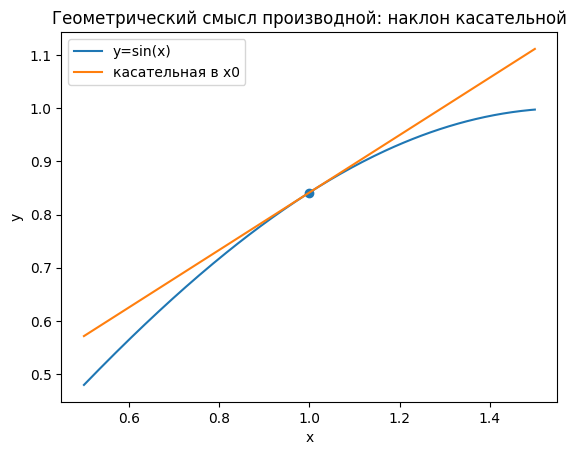

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 1.0
f = np.sin
df_true = np.cos(x0)

# строим маленькую окрестность
xs = np.linspace(x0-0.5, x0+0.5, 200)
ys = f(xs)

# касательная y = f(x0) + f'(x0)(x-x0)
tangent = f(x0) + df_true*(xs - x0)

plt.figure()
plt.plot(xs, ys, label="y=sin(x)")
plt.plot(xs, tangent, label="касательная в x0")
plt.scatter([x0], [f(x0)])
plt.legend()
plt.title("Геометрический смысл производной: наклон касательной")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 4. Понятие дифференцируемости и дифференциал

## 4.1. Дифференцируемость
Функция $y=f(x)$ **дифференцируема в точке** $x$, если её приращение можно представить как
$$
\Delta y = A\,\Delta x + o(\Delta x), \quad \Delta x\to 0,
$$
где $A$ — некоторое число, а $o(\Delta x)$ — величина, которая «меньше порядка» $\Delta x$:
$$
\frac{o(\Delta x)}{\Delta x}\to 0.
$$

В учебнике это вводится как основное определение дифференцируемости.

## 4.2. Связь с производной
Если функция дифференцируема, то существует производная и $A=f'(x)$.
И наоборот: существование производной в точке (в классическом смысле) влечёт дифференцируемость в этой точке.

## 4.3. Дифференциал
Главная линейная часть приращения:
$$
dy = A\,dx = f'(x)\,dx,
$$
где часто формально отождествляют $dx\equiv \Delta x$ как независимое «малое приращение».

**Важно для оптимизации:** это и есть локальная линейная аппроксимация, на которой держатся градиентные методы.


In [5]:
# Проверим на примере: f(x)=|x| в нуле: производная не существует
f = np.abs
x0 = 0.0
dxs = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5])

right = (f(x0 + dxs) - f(x0)) / dxs
left  = (f(x0 - dxs) - f(x0)) / (-dxs)

print("f(x)=|x|, x0=0")
print("Правые отношения Δy/Δx:", right)
print("Левые  отношения Δy/Δx:", left)
print("Вывод: пределы справа и слева разные => производная в 0 не существует.")

f(x)=|x|, x0=0
Правые отношения Δy/Δx: [1. 1. 1. 1. 1.]
Левые  отношения Δy/Δx: [-1. -1. -1. -1. -1.]
Вывод: пределы справа и слева разные => производная в 0 не существует.


# 5. Правила дифференцирования

## 5.1. Линейность (сумма/разность, константа)
Если $u(x)$ и $v(x)$ дифференцируемы в точке, то:
- $(u\pm v)' = u' \pm v'$
- $(c\,u)' = c\,u'$, где $c$ — константа

## 5.2. Произведение
$$
(u\,v)' = u'v + uv'.
$$

## 5.3. Частное
Если $v(x)\ne 0$, то
$$
\left(\frac{u}{v}\right)' = \frac{u'v-uv'}{v^2}.
$$

Эти формулы выводятся в учебнике через приращения и предельный переход.


In [6]:
# Небольшая численная проверка правила произведения
def d_central(f, x, dx=1e-6):
    return (f(x+dx) - f(x-dx)) / (2*dx)

x0 = 1.2
u = np.sin
v = np.exp

lhs = d_central(lambda x: u(x)*v(x), x0)
rhs = d_central(u, x0)*v(x0) + u(x0)*d_central(v, x0)

print("Проверка (u*v)' = u'*v + u*v' в x0 =", x0)
print("lhs:", lhs)
print("rhs:", rhs)
print("abs diff:", abs(lhs-rhs))

Проверка (u*v)' = u'*v + u*v' в x0 = 1.2
lhs: 4.2975488543373075
rhs: 4.297548854448054
abs diff: 1.1074607897398892e-10


# 6. Таблица производных простейших элементарных функций (шпаргалка)

| Функция $f(x)$ | Производная $f'(x)$ | Условия |
|---|---|---|
| $c$ | $0$ | $c$ — константа |
| $x$ | $1$ |  |
| $x^n$ | $n x^{n-1}$ | для целого $n$, далее по области определения |
| $\sqrt{x}=x^{1/2}$ | $\frac{1}{2\sqrt{x}}$ | $x>0$ |
| $1/x$ | $-1/x^2$ | $x\ne 0$ |
| $e^x$ | $e^x$ |  |
| $a^x$ | $a^x\ln a$ | $a>0, a\ne 1$ |
| $\ln x$ | $1/x$ | $x>0$ |
| $\log_a x$ | $1/(x\ln a)$ | $x>0$ |
| $\sin x$ | $\cos x$ |  |
| $\cos x$ | $-\sin x$ |  |
| $\tan x$ | $1/\cos^2 x$ | $\cos x\ne 0$ |
| $\cot x$ | $-1/\sin^2 x$ | $\sin x\ne 0$ |
| $\arcsin x$ | $1/\sqrt{1-x^2}$ | $|x|<1$ |
| $\arccos x$ | $-1/\sqrt{1-x^2}$ | $|x|<1$ |
| $\arctan x$ | $1/(1+x^2)$ |  |
| $\sinh x$ | $\cosh x$ |  |
| $\cosh x$ | $\sinh x$ |  |
| $\tanh x$ | $1/\cosh^2 x$ |  |



# 7. Правила дифференцирования сложных функций

## 7.1. Правило цепочки (Chain rule)
Если $y=f(u)$, где $u=\varphi(x)$, то сложная функция $y=f(\varphi(x))$ имеет производную:
$$
\frac{dy}{dx} = f'(\varphi(x))\cdot \varphi'(x).
$$

Учебник выводит это через представление приращения $\Delta y$ как линейной главной части плюс малое более высокого порядка.

## 7.2. Примеры
- $\frac{d}{dx}\sin(x^2) = \cos(x^2)\cdot 2x$
- $\frac{d}{dx}e^{\arctan x} = e^{\arctan x}\cdot \frac{1}{1+x^2}$

## 7.3. Связь с backprop
Backpropagation — это многократное применение Chain rule по вычислительному графу модели.


In [7]:
# Пример: производная sin(x^2) численно и аналитически
def f(x): return np.sin(x**2)
def fp(x): return np.cos(x**2) * 2*x

xs = np.array([0.1, 0.5, 1.0, 1.5])
dx = 1e-6
num = (f(xs+dx) - f(xs-dx)) / (2*dx)
ana = fp(xs)

print("x     num         ana         abs diff")
for x, n, a in zip(xs, num, ana):
    print(f"{x: .1f}  {n: .8f}  {a: .8f}  {abs(n-a): .2e}")

x     num         ana         abs diff
 0.1   0.19999000   0.19999000   5.21e-13
 0.5   0.96891242   0.96891242   1.29e-11
 1.0   1.08060461   1.08060461   7.73e-14
 1.5  -1.88452087  -1.88452087   1.45e-10


# 8. Производные высших порядков

## 8.1. Определение
Если $f'(x)$ дифференцируема, то определяют **вторую производную**:
$$
f''(x) = (f'(x))'.
$$
Аналогично определяются производные $n$-го порядка:
$$
f^{(n)}(x) = \frac{d^n f}{dx^n}.
$$

## 8.2. Примеры
- Если $f(x)=x^m$, то производные уменьшают степень, пока не получится 0.
- Если $f(x)=e^x$, то $f^{(n)}(x)=e^x$ для любого $n$.
- Если $f(x)=\sin x$, то производные цикличны с периодом 4:
  $\sin\to\cos\to-\sin\to-\cos\to\sin$.

## 8.3. Формула Лейбница для n-й производной произведения
Если $u$ и $v$ достаточно гладкие, то
$$
(uv)^{(n)} = \sum_{k=0}^n {n\choose k}\,u^{(k)}\,v^{(n-k)}.
$$
В учебнике это приводится как обобщение правила произведения (и доказывается индукцией).

## 8.4. Зачем это в DS
- Тейлоровы приближения (в т.ч. оценка погрешностей)
- Вторая производная: кривизна, Hessian, Newton/Quasi-Newton методы
- Регуляризация и анализ гладкости функций потерь


In [8]:
# Пример цикличности производных sin: f, f', f'', f''', f''''
import numpy as np

def sin_derivative_order(n, x):
    # значения производных sin(x) по циклу
    n_mod = n % 4
    if n_mod == 0: return np.sin(x)
    if n_mod == 1: return np.cos(x)
    if n_mod == 2: return -np.sin(x)
    return -np.cos(x)

x0 = 0.7
for n in range(0, 9):
    print(f"n={n}  f^(n)(x0)={sin_derivative_order(n, x0): .8f}")

n=0  f^(n)(x0)= 0.64421769
n=1  f^(n)(x0)= 0.76484219
n=2  f^(n)(x0)=-0.64421769
n=3  f^(n)(x0)=-0.76484219
n=4  f^(n)(x0)= 0.64421769
n=5  f^(n)(x0)= 0.76484219
n=6  f^(n)(x0)=-0.64421769
n=7  f^(n)(x0)=-0.76484219
n=8  f^(n)(x0)= 0.64421769


In [9]:
# Проверка формулы Лейбница численно для u=sin, v=exp, n=3
import numpy as np

def d_numerical(f, x, dx=1e-4, n=1):
    # простая рекурсия через центральную разность (для демонстрации; точность ограничена)
    if n == 0:
        return f(x)
    return (d_numerical(f, x+dx, dx, n-1) - d_numerical(f, x-dx, dx, n-1)) / (2*dx)

x0 = 0.5
u = np.sin
v = np.exp
n = 3

lhs = d_numerical(lambda x: u(x)*v(x), x0, n=n)

# правая часть
from math import comb
rhs = 0.0
for k in range(n+1):
    rhs += comb(n, k) * d_numerical(u, x0, n=k) * d_numerical(v, x0, n=n-k)

print("Leibniz n=3 at x0 =", x0)
print("lhs:", lhs)
print("rhs:", rhs)
print("abs diff:", abs(lhs-rhs))

Leibniz n=3 at x0 = 0.5
lhs: 1.3129081155582867
rhs: 1.312920342363671
abs diff: 1.2226805384374373e-05


# 9. Дифференциалы и приближения (связь с линейной аппроксимацией)

## 9.1. Линейное приближение
Если функция дифференцируема, то при малых $\Delta x$:
$$
\Delta y \approx f'(x)\,\Delta x.
$$
То есть приращение функции примерно равно дифференциалу первого порядка.

## 9.2. Инвариантность формы первого дифференциала
В учебнике отдельно обсуждается важный факт:
если $y=f(u)$, а $u=\varphi(x)$, то
$$
dy = f'(u)\,du, \quad du = \varphi'(x)\,dx,
$$
и, подставляя, получаем тот же chain rule:
$$
\frac{dy}{dx} = f'(\varphi(x))\,\varphi'(x).
$$

## 9.3. Второй дифференциал (идея)
Если есть вторая производная, то для независимой переменной $x$:
$$
d^2y = f''(x)\,(dx)^2.
$$
Это полезно, когда обсуждают приближения второго порядка и методы Ньютона.


In [10]:
# Демонстрация линейного приближения: exp(x) около x0
import numpy as np

x0 = 0.0
f = np.exp
fp = np.exp  # производная exp

dxs = np.array([1e-1, 1e-2, 1e-3])
for dx in dxs:
    delta = f(x0+dx) - f(x0)
    lin = fp(x0)*dx
    print(f"dx={dx: .0e}  Δy={delta: .10f}  линейно={lin: .10f}  ошибка={abs(delta-lin):.2e}")

dx= 1e-01  Δy= 0.1051709181  линейно= 0.1000000000  ошибка=5.17e-03
dx= 1e-02  Δy= 0.0100501671  линейно= 0.0100000000  ошибка=5.02e-05
dx= 1e-03  Δy= 0.0010005002  линейно= 0.0010000000  ошибка=5.00e-07


# 10. Производная функции, заданной параметрически

Если кривая задана параметрически:
$$
x=\varphi(t),\quad y=\psi(t),
$$
то при $\varphi'(t)\ne 0$ производная:
$$
\frac{dy}{dx} = \frac{dy/dt}{dx/dt} = \frac{\psi'(t)}{\varphi'(t)}.
$$

Это особенно полезно в геометрии и в задачах моделирования траекторий (например, в физике/робототехнике).


In [11]:
# Пример параметрической кривой: окружность x=cos t, y=sin t -> dy/dx = -cot t
import numpy as np

ts = np.array([0.5, 1.0, 1.2])  # избегаем t=0,pi...
x = np.cos(ts)
y = np.sin(ts)

dxdt = -np.sin(ts)
dydt = np.cos(ts)
dydx = dydt/dxdt

print("t     x       y      dy/dx(param)    теоретически -cot(t)")
for t, xv, yv, r in zip(ts, x, y, dydx):
    print(f"{t: .2f}  {xv: .6f}  {yv: .6f}  {r: .6f}       {-1/np.tan(t): .6f}")

t     x       y      dy/dx(param)    теоретически -cot(t)
 0.50   0.877583   0.479426  -1.830488       -1.830488
 1.00   0.540302   0.841471  -0.642093       -0.642093
 1.20   0.362358   0.932039  -0.388780       -0.388780



# 11. Градиент (для функций многих переменных)

## 11.1. Определение
Пусть задана скалярная функция многих переменных:
$$
f(\mathbf{x}) = f(x_1, x_2, \dots, x_n).
$$
Её **градиент** — это вектор из частных производных:
$$
\nabla f(\mathbf{x}) =
\begin{pmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{pmatrix}.
$$

**Градиент — это вектор, компонентами которого являются частные производные** (в выбранном базисе координат).

## 11.2. Геометрический смысл
- $\nabla f(\mathbf{x})$ указывает направление **наибольшего возрастания** функции в точке.
- Длина $\|\nabla f(\mathbf{x})\|$ — это максимальная скорость роста (по единичным направлениям).
- Уровенные поверхности/линии $f(\mathbf{x})=\text{const}$: градиент **перпендикулярен** уровню (нормаль к уровенной линии/поверхности).

## 11.3. Связь с дифференциалом
Для малых приращений $\Delta\mathbf{x}$:
$$
\Delta f \approx df = \nabla f(\mathbf{x})^\top \Delta \mathbf{x}.
$$
Это прямое многомерное обобщение идеи линейной аппроксимации из 1D-случая.

## 11.4. Как градиент используется в ML
В ML обычно минимизируют функцию потерь $L(\theta)$ по параметрам модели $\theta$.
- **Gradient Descent**:
$$
\theta_{k+1} = \theta_k - \eta \nabla_\theta L(\theta_k),
$$
где $\eta$ — learning rate.
- **Backpropagation** — это эффективный способ вычислить $\nabla_\theta L$ в нейросетях (многократное применение chain rule по вычислительному графу).
- Знак «минус» потому, что градиент направлен на **рост**, а для минимума мы идём в сторону **убывания**.

---


In [12]:
import numpy as np

# Аналитический градиент для f(x, y) = x^2 + 3y^2 + 2xy
def f_xy(xy):
    x, y = xy
    return x**2 + 3*y**2 + 2*x*y

def grad_f_xy(xy):
    x, y = xy
    # ∂f/∂x = 2x + 2y
    # ∂f/∂y = 6y + 2x
    return np.array([2*x + 2*y, 6*y + 2*x], dtype=float)

p = np.array([1.0, -1.0])
print("Точка p =", p)
print("f(p) =", f_xy(p))
print("∇f(p) =", grad_f_xy(p))
print("Норма градиента ||∇f|| =", np.linalg.norm(grad_f_xy(p)))

Точка p = [ 1. -1.]
f(p) = 2.0
∇f(p) = [ 0. -4.]
Норма градиента ||∇f|| = 4.0


In [13]:
import numpy as np

# Численный градиент (finite differences) — полезно для gradient checking
def numerical_grad(f, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x)):
        x1 = x.copy(); x1[i] += eps
        x2 = x.copy(); x2[i] -= eps
        g[i] = (f(x1) - f(x2)) / (2*eps)
    return g

p = np.array([1.0, -1.0])
g_num = numerical_grad(f_xy, p)
g_ana = grad_f_xy(p)

print("Численный ∇f(p):", g_num)
print("Аналитический ∇f(p):", g_ana)
print("Абс.разница:", np.abs(g_num - g_ana))

Численный ∇f(p): [ 2.22044605e-10 -4.00000000e+00]
Аналитический ∇f(p): [ 0. -4.]
Абс.разница: [2.22044605e-10 2.18044249e-10]


Стартовая точка: [2.5 2. ] f = 28.25
Конечная точка : [ 0.03395128 -0.01406308] f = 0.0007910807574369663


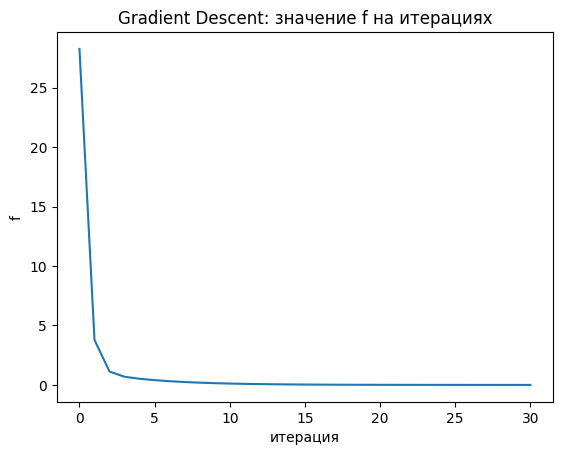

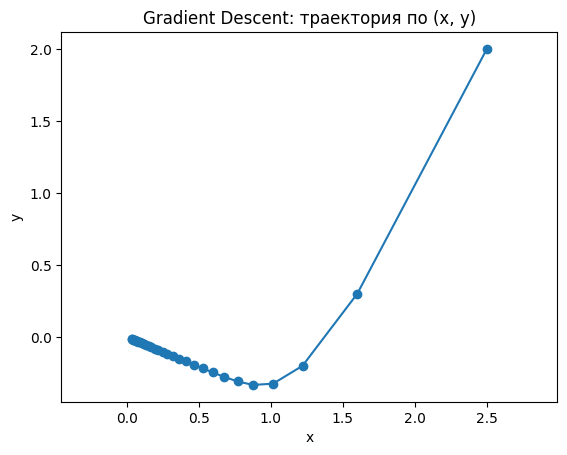

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Демонстрация gradient descent на 2D квадратичной функции
# f(x, y) = x^2 + 3y^2 + 2xy (выпуклая "чаша")
def f_xy(xy):
    x, y = xy
    return x**2 + 3*y**2 + 2*x*y

def grad_f_xy(xy):
    x, y = xy
    return np.array([2*x + 2*y, 6*y + 2*x], dtype=float)

eta = 0.1
steps = 30
x = np.array([2.5, 2.0], dtype=float)

trajectory = [x.copy()]
values = [f_xy(x)]

for _ in range(steps):
    x = x - eta * grad_f_xy(x)
    trajectory.append(x.copy())
    values.append(f_xy(x))

trajectory = np.array(trajectory)

print("Стартовая точка:", trajectory[0], "f =", values[0])
print("Конечная точка :", trajectory[-1], "f =", values[-1])

plt.figure()
plt.plot(values)
plt.title("Gradient Descent: значение f на итерациях")
plt.xlabel("итерация")
plt.ylabel("f")
plt.show()

plt.figure()
plt.plot(trajectory[:,0], trajectory[:,1], marker="o")
plt.title("Gradient Descent: траектория по (x, y)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()